# Initial data EDA

## Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df_2015 = pd.read_csv("../data/raw/2015.csv")
df_2016 = pd.read_csv("../data/raw/2016.csv")
df_2017 = pd.read_csv("../data/raw/2017.csv")
df_2018 = pd.read_csv("../data/raw/2018.csv")
df_2019 = pd.read_csv("../data/raw/2019.csv")

## gruop

In [3]:
for year, df in [(2015, df_2015), (2016, df_2016), (2017, df_2017), (2018, df_2018), (2019, df_2019)]:
    print(f"\n--- {year} ---")
    print(df.columns.tolist())


--- 2015 ---
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

--- 2016 ---
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

--- 2017 ---
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']

--- 2018 ---
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

--- 2019 ---
['Overall rank', 'Country or region'

In [4]:
def normalize_df(df, year):
    rename_map = {
        # Country
        "Country": "country",
        "Country or region": "country",
        
        # Rank
        "Happiness Rank": "rank",
        "Happiness.Rank": "rank",
        "Overall rank": "rank",
        
        # Score
        "Happiness Score": "happiness_score",
        "Happiness.Score": "happiness_score",
        "Score": "happiness_score",
        
        # GDP
        "Economy (GDP per Capita)": "gdp_per_capita",
        "Economy..GDP.per.Capita.": "gdp_per_capita",
        "GDP per capita": "gdp_per_capita",
        
        # social support
        "Family": "social_support",
        "Social support": "social_support",
        
        # Shealth
        "Health (Life Expectancy)": "life_expectancy",
        "Health..Life.Expectancy.": "life_expectancy",
        "Healthy life expectancy": "life_expectancy",
        
        # freedom
        "Freedom": "freedom",
        "Freedom to make life choices": "freedom",
        
        # corruption
        "Trust (Government Corruption)": "corruption",
        "Trust..Government.Corruption.": "corruption",
        "Perceptions of corruption": "corruption",
        
        # generosity
        "Generosity": "generosity",
    }
    
    df = df.rename(columns=rename_map)
    
    cols = ["country", "rank", "happiness_score", "gdp_per_capita",
            "social_support", "life_expectancy", "freedom", "generosity", "corruption"]
    
   
    df = df[[c for c in cols if c in df.columns]].copy()
    df["year"] = year
    
    return df

df_2015n = normalize_df(df_2015, 2015)
df_2016n = normalize_df(df_2016, 2016)
df_2017n = normalize_df(df_2017, 2017)
df_2018n = normalize_df(df_2018, 2018)
df_2019n = normalize_df(df_2019, 2019)

df = pd.concat([df_2015n, df_2016n, df_2017n, df_2018n, df_2019n], ignore_index=True)

print(df.shape)
print(df.columns.tolist())
df.head()

(782, 10)
['country', 'rank', 'happiness_score', 'gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'generosity', 'corruption', 'year']


,country,rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015


## Nulls

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          782 non-null    str    
 1   rank             782 non-null    int64  
 2   happiness_score  782 non-null    float64
 3   gdp_per_capita   782 non-null    float64
 4   social_support   782 non-null    float64
 5   life_expectancy  782 non-null    float64
 6   freedom          782 non-null    float64
 7   generosity       782 non-null    float64
 8   corruption       781 non-null    float64
 9   year             782 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 61.2 KB


In [6]:
print(df.isnull().sum())

country            0
rank               0
happiness_score    0
gdp_per_capita     0
social_support     0
life_expectancy    0
freedom            0
generosity         0
corruption         1
year               0
dtype: int64


In [7]:
# fill NANs wiht median by year
df["corruption"] = df.groupby("year")["corruption"].transform(
    lambda x: x.fillna(x.median())
)

# Verificar que no queden nulos
print(df.isnull().sum())

country            0
rank               0
happiness_score    0
gdp_per_capita     0
social_support     0
life_expectancy    0
freedom            0
generosity         0
corruption         0
year               0
dtype: int64


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          782 non-null    str    
 1   rank             782 non-null    int64  
 2   happiness_score  782 non-null    float64
 3   gdp_per_capita   782 non-null    float64
 4   social_support   782 non-null    float64
 5   life_expectancy  782 non-null    float64
 6   freedom          782 non-null    float64
 7   generosity       782 non-null    float64
 8   corruption       782 non-null    float64
 9   year             782 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 61.2 KB


## EDA

In [9]:
df.describe()

,rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,year
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,78.698210,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125380,2016.993606
std,45.182384,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105760,1.417364
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,40.000000,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054250,2016.000000
50%,79.000000,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.090905,2017.000000
75%,118.000000,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.155861,2018.000000
max,158.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910,2019.000000


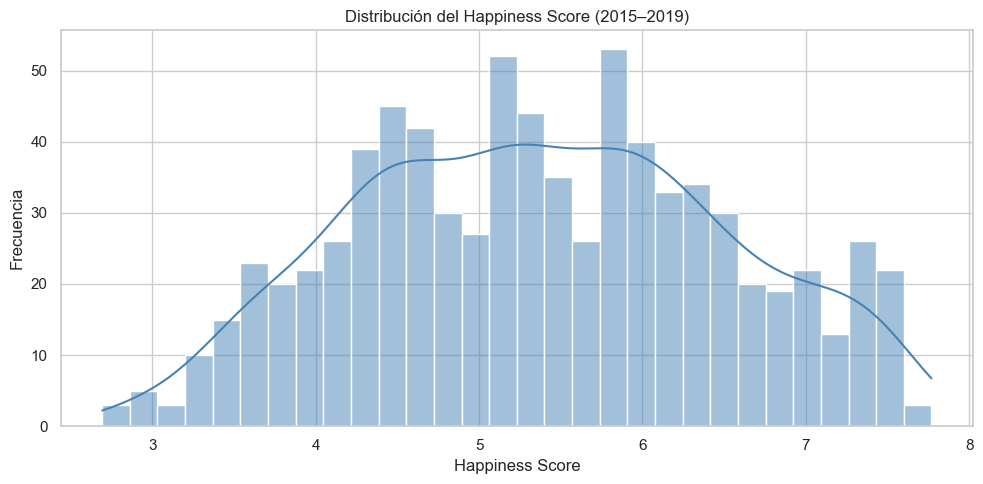

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["happiness_score"], bins=30, kde=True, color="steelblue")
plt.title("Distribución del Happiness Score (2015–2019)")
plt.xlabel("Happiness Score")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

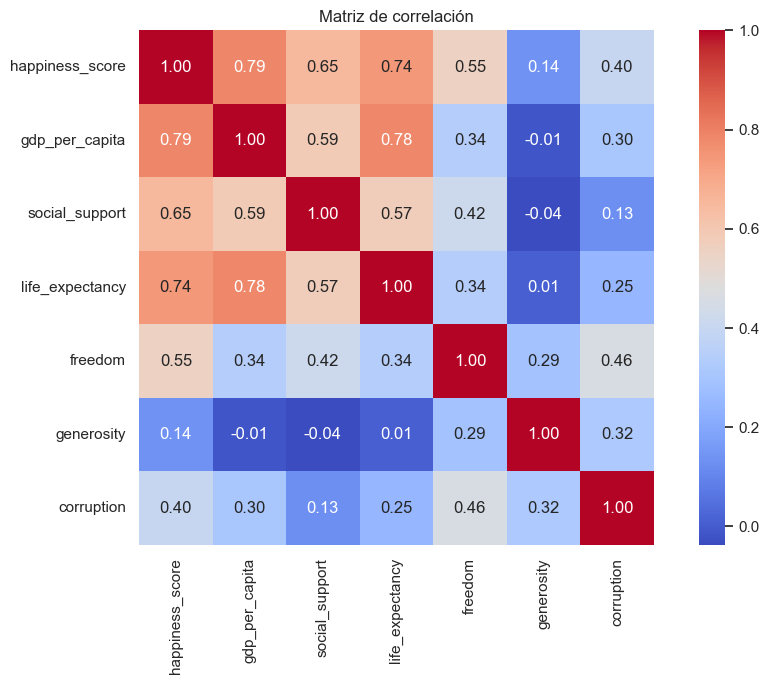

In [11]:
plt.figure(figsize=(10, 7))
corr = df[["happiness_score", "gdp_per_capita", "social_support",
           "life_expectancy", "freedom", "generosity", "corruption"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

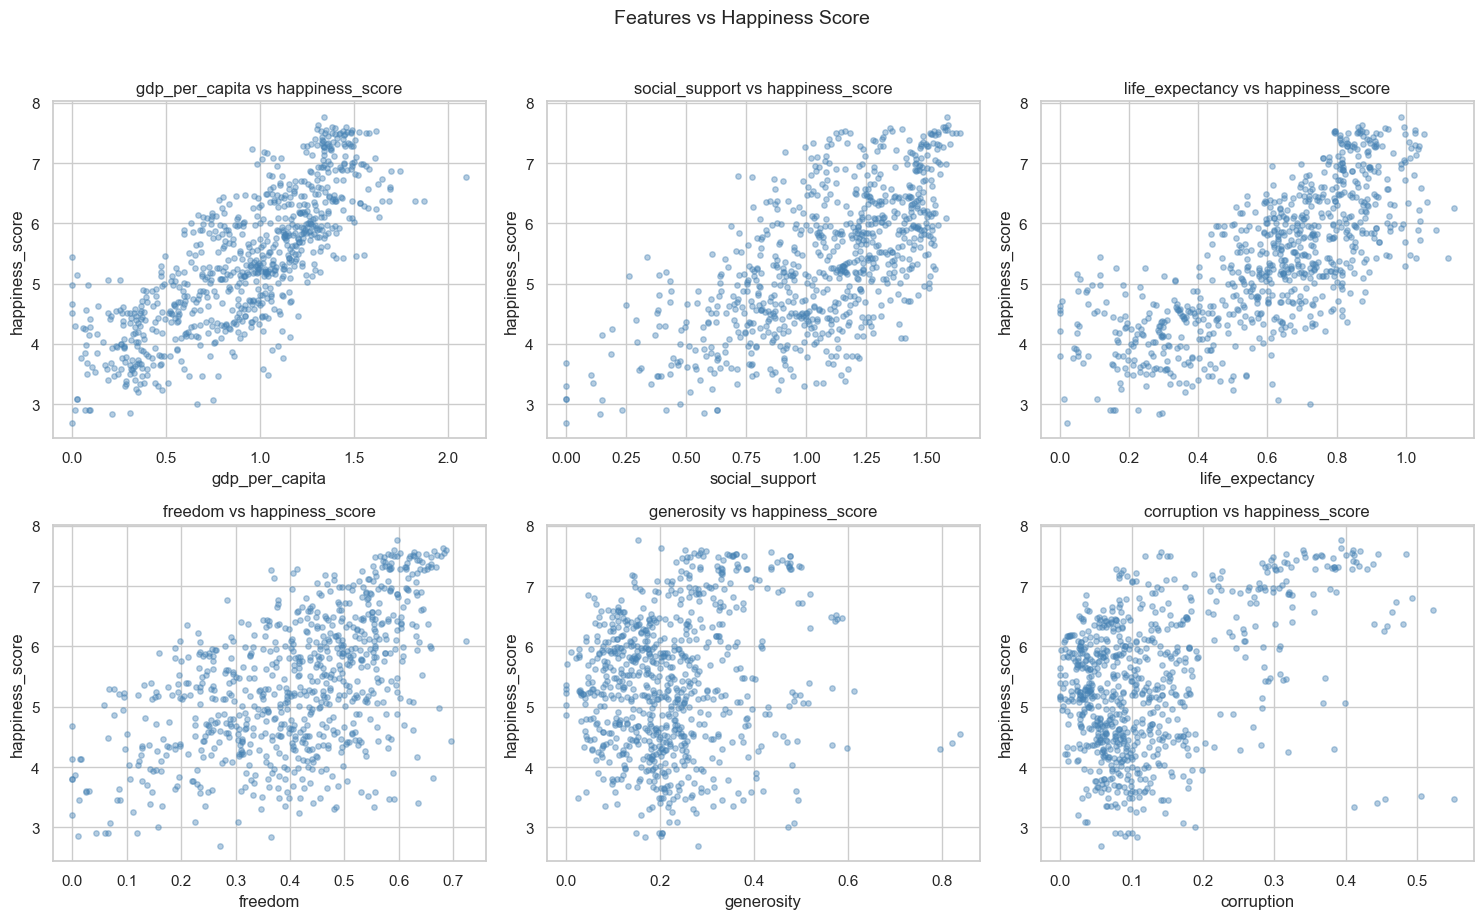

In [12]:
features = ["gdp_per_capita", "social_support", "life_expectancy",
            "freedom", "generosity", "corruption"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df["happiness_score"], alpha=0.4, color="steelblue", s=15)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("happiness_score")
    axes[i].set_title(f"{feature} vs happiness_score")

plt.suptitle("Features vs Happiness Score", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

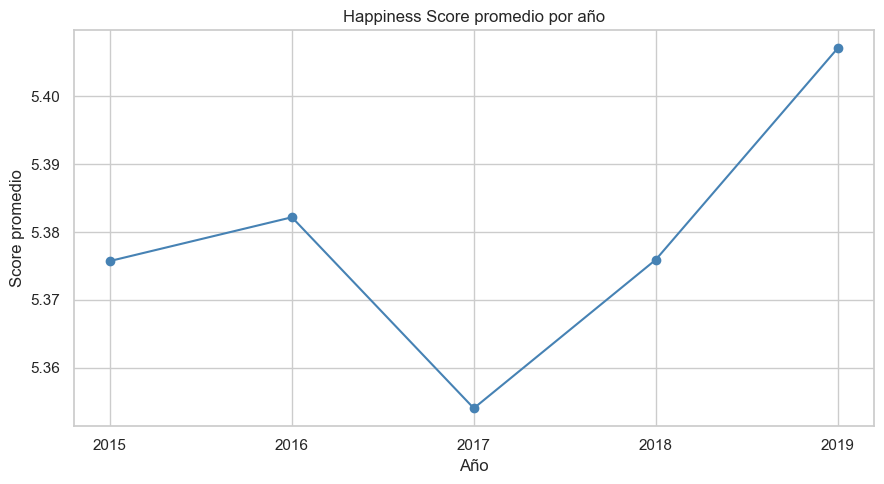

In [13]:
plt.figure(figsize=(9, 5))
df.groupby("year")["happiness_score"].mean().plot(marker="o", color="steelblue")
plt.title("Happiness Score promedio por año")
plt.xlabel("Año")
plt.ylabel("Score promedio")
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.tight_layout()
plt.show()

## Save data

In [14]:
df.to_csv("../data/processed/happiness_dataset.csv", index=False)
print(f"Dataset guardado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset guardado: 782 filas, 10 columnas
